In [22]:
import pandas as pd

# Updated file path to a local one that works
url = "/content/drive/MyDrive/Machine Learning/Praktikum 11 | K-Means Clustering/data/covid_19_indonesia_time_series_all.csv"
df = pd.read_csv(url)

# Adjust column selection based on the new dataset's available columns
# 'Location' column is used as the primary geographical identifier for province/region.
df = df[['Location','Total Cases','Latitude','Longitude']]
df.dropna(inplace=True)

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31822 entries, 0 to 31821
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Location     31822 non-null  object 
 1   Total Cases  31822 non-null  int64  
 2   Latitude     31822 non-null  float64
 3   Longitude    31822 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 994.6+ KB


In [24]:
import folium
from folium.plugins import HeatMap

m = folium.Map(location=[-2,118], zoom_start=5)  # posisi tengah Indonesia
heat_data = df[['Latitude','Longitude','Total Cases']].values.tolist()
HeatMap(heat_data, radius=10).add_to(m)
m

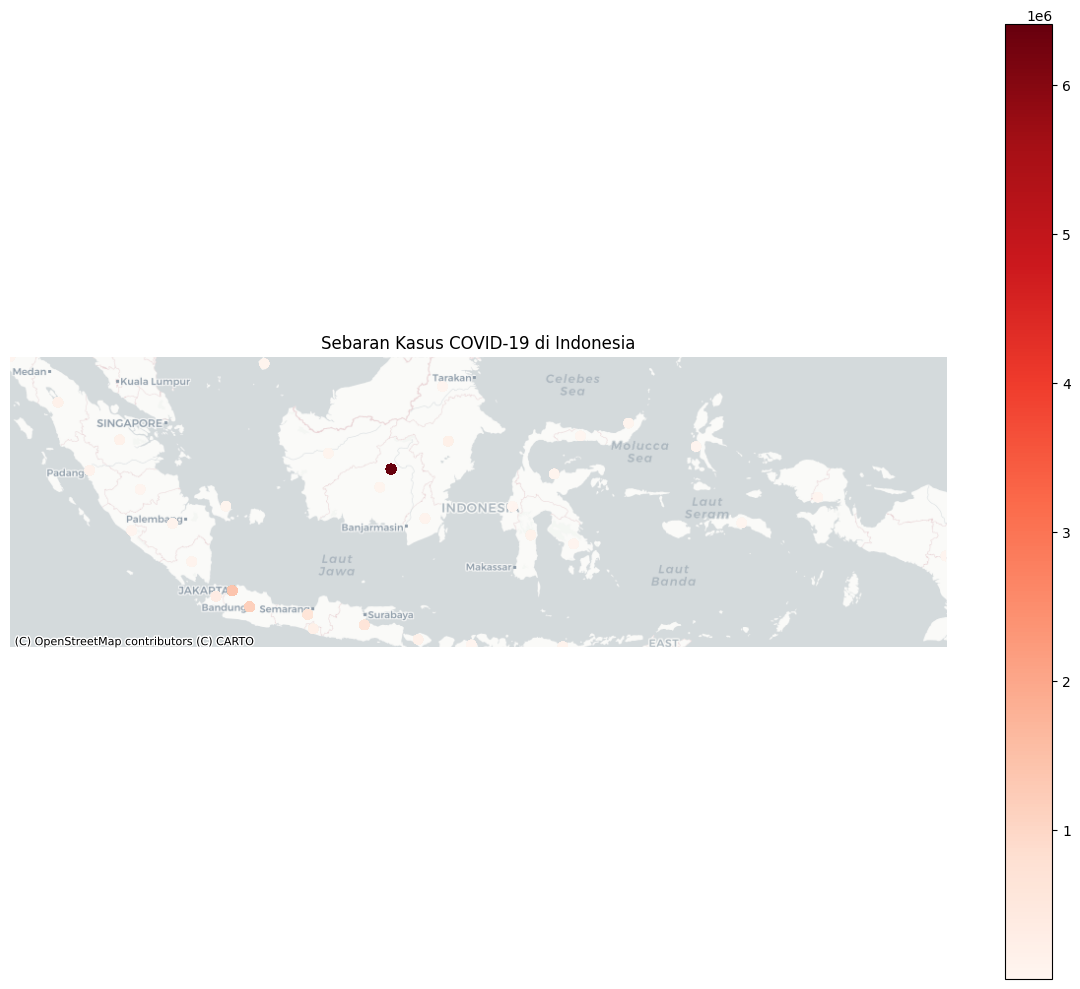

In [26]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude'])
)
gdf = gdf.set_crs(epsg=4326).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(
    ax=ax,
    column='Total Cases',
    cmap='Reds',
    legend=True,
    markersize=40,
    alpha=0.8
)

# Zoom otomatis seluruh Indonesia
xmin, ymin, xmax, ymax = gdf.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
plt.title("Sebaran Kasus COVID-19 di Indonesia")
plt.tight_layout()
plt.show()

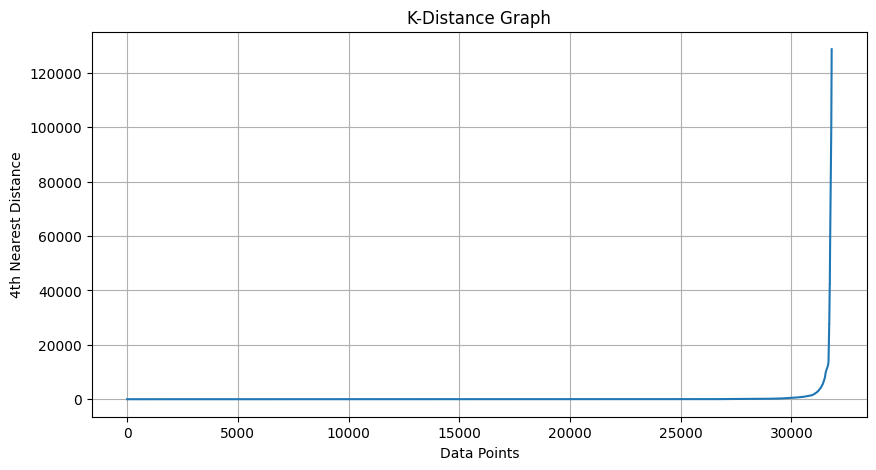

In [27]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

X = df[['Total Cases','Latitude','Longitude']]  # fitur numerik

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Urutkan jarak tetangga ke-4 untuk menemukan siku
distances = np.sort(distances[:,4])

plt.figure(figsize=(10,5))
plt.plot(distances)
plt.title('K-Distance Graph')
plt.xlabel('Data Points')
plt.ylabel('4th Nearest Distance')
plt.grid(True)
plt.show()


In [28]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.35, min_samples=8).fit(X)
df['Cluster'] = dbscan.labels_
print(df['Cluster'].value_counts())


Cluster
-1     30694
 73       40
 43       29
 44       28
 80       27
       ...  
 60        8
 72        8
 78        8
 86        8
 90        8
Name: count, Length: 92, dtype: int64


In [29]:
from sklearn.metrics import silhouette_score

valid = df[df['Cluster'] != -1]          # noise dikeluarkan dulu
X_valid = valid[['Total Cases','Latitude','Longitude']]

score = silhouette_score(X_valid, valid['Cluster'])
print("Silhouette Score:", score)


Silhouette Score: 0.9999999333830148


In [34]:
import plotly.express as px

# Add PCA results to the DataFrame for plotting
df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

fig = px.scatter(
    df,
    x='PCA1',
    y='PCA2',
    color='Cluster',
    hover_data=['Location','Total Cases'] # Removed 'City' and 'Province', used 'Location' instead
)
fig.show()

In [35]:
summary = df.groupby('Cluster')[['Total Cases']].mean()
summary


,Total Cases
Cluster,
-1,164721.330032
0,1.000000
1,45.000000
2,1.000000
3,6.000000
...,...
86,15566.000000
87,29124.000000
88,29130.000000
